# T1 - Tic Tac Toe com Machine Learning
## Algoritmo KNN

Neste notebook foi desenvolvido um modelo de classificação utilizando o algoritmo K-Nearest Neighbors (KNN) para identificar estados do jogo da velha.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

## Carregamento dos datasets

Os dados foram previamente divididos em:
- treino;
- validação;
- teste.

In [ ]:
treino = pd.read_csv('../data/processed/treino.csv')
validacao = pd.read_csv('../data/processed/validacao.csv')
teste = pd.read_csv('../data/processed/teste.csv')

print("Treino:", treino.shape)
print("Validação:", validacao.shape)
print("Teste:", teste.shape)

Treino: (489, 10)
Validação: (163, 10)
Teste: (164, 10)


## Análise inicial do dataset

As colunas representam posições do tabuleiro:
- tl: top-left;
- tm: top-middle;
- tr: top-right;
- ml: middle-left;
- mm: middle-middle;
- mr: middle-right;
- bl: bottom-left;
- bm: bottom-middle;
- br: bottom-right.

Os valores foram serializados numericamente:
- 0 = vazio;
- 1 = O;
- 2 = X.

In [ ]:
treino.describe()

,tl,tm,tr,ml,mm,mr,bl,bm,br,classe_id
count,489.000000,489.000000,489.000000,489.000000,489.000000,489.000000,489.000000,489.000000,489.000000,489.000000
mean,1.026585,1.018405,0.991820,1.036810,0.950920,1.049080,1.012270,1.006135,0.889571,2.453988
std,0.837950,0.843046,0.834658,0.843657,0.815855,0.843031,0.841942,0.833447,0.849345,1.158729
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
75%,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000
max,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,4.000000


## Visualização inicial das amostras

Abaixo é possível visualizar algumas instâncias do dataset. Cada linha representa um estado possível do tabuleiro do jogo da velha.

In [ ]:
treino.head()

,tl,tm,tr,ml,mm,mr,bl,bm,br,classe_id
0,0,0,2,1,2,1,0,2,0,2
1,2,0,2,1,2,2,1,1,1,1
2,2,0,0,2,1,2,1,0,0,2
3,2,1,1,0,2,1,0,2,2,4
4,2,1,0,1,2,2,0,2,1,3


## Separação das variáveis de entrada e saída

As posições do tabuleiro foram utilizadas como variáveis de entrada (features), enquanto a coluna `classe_id` foi utilizada como variável alvo (target).

Também foram utilizados conjuntos separados de treino, validação e teste:
- treino → treinamento do modelo;
- validação → escolha do melhor valor de K;
- teste → avaliação final do algoritmo.

In [ ]:
colunas_features = ['tl', 'tm', 'tr',
                    'ml', 'mm', 'mr',
                    'bl', 'bm', 'br']

X_train = treino[colunas_features]
y_train = treino['classe_id']

X_val = validacao[colunas_features]
y_val = validacao['classe_id']

X_test = teste[colunas_features]
y_test = teste['classe_id']


X_train.head()

,tl,tm,tr,ml,mm,mr,bl,bm,br
0,0,0,2,1,2,1,0,2,0
1,2,0,2,1,2,2,1,1,1
2,2,0,0,2,1,2,1,0,0
3,2,1,1,0,2,1,0,2,2
4,2,1,0,1,2,2,0,2,1


## Verificação das dimensões dos conjuntos

Foi realizada a verificação das dimensões dos conjuntos de treino, validação e teste para garantir que:
- todos possuem 9 atributos de entrada;
- as quantidades de amostras estão corretas;
- a separação dos dados foi realizada corretamente.

In [ ]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (489, 9)
y_train: (489,)
X_val: (163, 9)
y_val: (163,)
X_test: (164, 9)
y_test: (164,)


## Visualização das entradas e saídas do modelo

Abaixo são apresentadas algumas amostras das entradas utilizadas pelo modelo (`X`) e suas respectivas classes esperadas (`y`).

In [ ]:
print("=== X_train ===")
print(X_train.head())

print("\n=== y_train ===")
print(y_train.head())

print("\n=== X_test ===")
print(X_test.head())

print("\n=== y_test ===")
print(y_test.head())

=== X_train ===
   tl  tm  tr  ml  mm  mr  bl  bm  br
0   0   0   2   1   2   1   0   2   0
1   2   0   2   1   2   2   1   1   1
2   2   0   0   2   1   2   1   0   0
3   2   1   1   0   2   1   0   2   2
4   2   1   0   1   2   2   0   2   1

=== y_train ===
0    2
1    1
2    2
3    4
4    3
Name: classe_id, dtype: int64

=== X_test ===
   tl  tm  tr  ml  mm  mr  bl  bm  br
0   1   2   1   2   2   2   1   1   2
1   0   1   2   2   2   2   0   1   1
2   2   2   2   2   1   0   1   1   0
3   2   1   2   1   0   2   0   1   2
4   1   2   2   0   1   1   2   2   1

=== y_test ===
0    4
1    4
2    4
3    4
4    1
Name: classe_id, dtype: int64


In [ ]:
print("\nClasses presentes no treino:")
print(y_train.value_counts())


Classes presentes no treino:
classe_id
2    120
1    120
4    120
3    120
0      9
Name: count, dtype: int64


A distribuição das classes no conjunto de treino mostra que a classe de empate possui significativamente menos amostras do que as demais classes.

Esse desbalanceamento pode impactar o desempenho do algoritmo em algumas métricas, especialmente para a identificação correta de empates.

## Normalização dos dados

O StandardScaler foi utilizado para padronizar os valores de entrada antes da aplicação do K-NN.

Apesar das variáveis já estarem codificadas numericamente, a normalização foi mantida para garantir um tratamento uniforme dos dados durante o cálculo das distâncias.

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   #aprende a escala no treino e já transforma
X_val_scaled = scaler.transform(X_val)           #aplica a mesma escala na validação
X_test_scaled = scaler.transform(X_test)         #aplica a mesma escala no teste

## Escolha do melhor valor de K

Nesta etapa foram testados diferentes valores de `k`, de 1 até 30.

O conjunto de validação foi utilizado para comparar o desempenho de cada configuração, evitando escolher o melhor parâmetro diretamente pelo conjunto de teste.

In [ ]:
resultados_k = []

melhor_k = 0
melhor_acuracia = 0

for k in range(1, 31):
    knn = KNeighborsClassifier(n_neighbors=k)    #cria o modelo com o valor atual de k
    knn.fit(X_train_scaled, y_train)             #"treina" o modelo com os dados de treino (memoriza)
    y_val_pred = knn.predict(X_val_scaled)       #faz as predições no conjunto de validação (executa knn)
    acuracia = accuracy_score(y_val, y_val_pred) #calcula a acurácia na validação

    resultados_k.append({
        "k": k,
        "acuracia_validacao": acuracia
    })

    print(f"k = {k}, acurácia = {acuracia:.4f}")

    if acuracia > melhor_acuracia:
        melhor_acuracia = acuracia
        melhor_k = k

print(f"\nMelhor k: {melhor_k}")
print(f"Melhor acurácia na validação: {melhor_acuracia:.4f}")

k = 1, acurácia = 0.5583
k = 2, acurácia = 0.4969
k = 3, acurácia = 0.5583
k = 4, acurácia = 0.5399
k = 5, acurácia = 0.5276
k = 6, acurácia = 0.5460
k = 7, acurácia = 0.5276
k = 8, acurácia = 0.5031
k = 9, acurácia = 0.5215
k = 10, acurácia = 0.5153
k = 11, acurácia = 0.5092
k = 12, acurácia = 0.5337
k = 13, acurácia = 0.5031
k = 14, acurácia = 0.5215
k = 15, acurácia = 0.5521
k = 16, acurácia = 0.5583
k = 17, acurácia = 0.5644
k = 18, acurácia = 0.5583
k = 19, acurácia = 0.5890
k = 20, acurácia = 0.5890
k = 21, acurácia = 0.5644
k = 22, acurácia = 0.5399
k = 23, acurácia = 0.5583
k = 24, acurácia = 0.5215
k = 25, acurácia = 0.5031
k = 26, acurácia = 0.4908
k = 27, acurácia = 0.5215
k = 28, acurácia = 0.5153
k = 29, acurácia = 0.4847
k = 30, acurácia = 0.4540

Melhor k: 19
Melhor acurácia na validação: 0.5890


O melhor resultado foi obtido com k = 19, alcançando cerca de 58,90% de acurácia no conjunto de validação.

Também foi possível perceber que valores muito baixos e muito altos de k tiveram resultados piores. Além disso, o desempenho do algoritmo pode ter sido afetado pelo desbalanceamento da classe de empate e pelo fato dos dados serem categóricos.

## Avaliação final no conjunto de teste

Após encontrar o melhor valor de `k` utilizando o conjunto de validação, o modelo foi treinado novamente e avaliado no conjunto de teste.

Essa etapa representa a avaliação final do algoritmo, utilizando dados que não participaram do treinamento nem da escolha dos hiperparâmetros.

In [ ]:
#classificando os dados do dataset de teste com o melhor k

knn_final = KNeighborsClassifier(n_neighbors=melhor_k)
knn_final.fit(X_train_scaled, y_train)

y_test_pred = knn_final.predict(X_test_scaled)
test_acc = accuracy_score(y_test, y_test_pred)

print("Acurácia no teste:", test_acc)

Acurácia no teste: 0.5487804878048781


O modelo obteve aproximadamente 54,88% de acurácia no conjunto de teste.

As classes 3 e 4 apresentaram os melhores resultados (classification_report), enquanto a classe 0 teve desempenho muito baixo, principalmente pela baixa quantidade de exemplos presentes no dataset.

O modelo conseguiu diferenciar parte das configurações do tabuleiro presentes no dataset, porém ainda apresentou dificuldade para diferenciar algumas classes.

## Relatório de classificação

Além da acurácia geral, também foi analisado o desempenho individual de cada classe utilizando precision, recall e f1-score.

As classes 3 e 4 apresentaram os melhores resultados, enquanto a classe 0 teve desempenho muito baixo devido à pequena quantidade de exemplos presentes no dataset de teste.

A acurácia final do modelo ficou próxima de 55%, mostrando que o K-NN conseguiu identificar parte dos padrões do jogo da velha, mas ainda apresentou dificuldades em algumas classificações.

In [ ]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.46      0.65      0.54        40
           2       0.44      0.35      0.39        40
           3       0.68      0.65      0.67        40
           4       0.65      0.60      0.62        40

    accuracy                           0.55       164
   macro avg       0.45      0.45      0.44       164
weighted avg       0.54      0.55      0.54       164



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Matriz de confusão

A matriz de confusão permite visualizar com mais detalhes quais classes o modelo conseguiu classificar corretamente e quais classes foram confundidas entre si.

Os valores presentes na diagonal principal representam os acertos do modelo. Já os demais valores representam erros de classificação.

É possível observar que as classes 3 e 4 tiveram maior quantidade de acertos, enquanto algumas classes, principalmente a 2, apresentaram mais confusões com outras categorias.

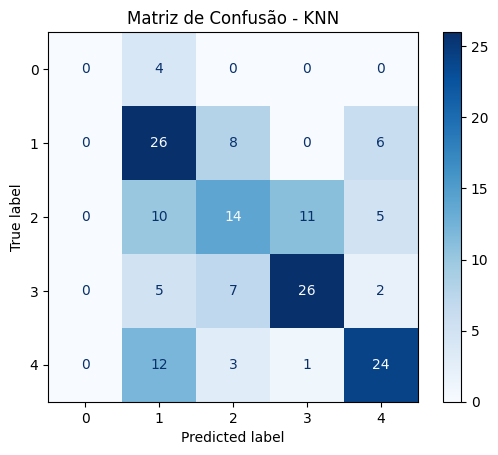

In [ ]:
cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap='Blues')

plt.title("Matriz de Confusão - KNN")
plt.show()

## Gráfico de acurácia por valor de K

O gráfico mostra a variação da acurácia do modelo conforme diferentes valores de `k` foram testados.

Foi possível observar que os melhores resultados ocorreram próximos de `k = 19` e `k = 20`, onde a acurácia atingiu aproximadamente 58,9%.

Também é possível perceber que valores muito altos de `k` reduziram o desempenho do modelo.

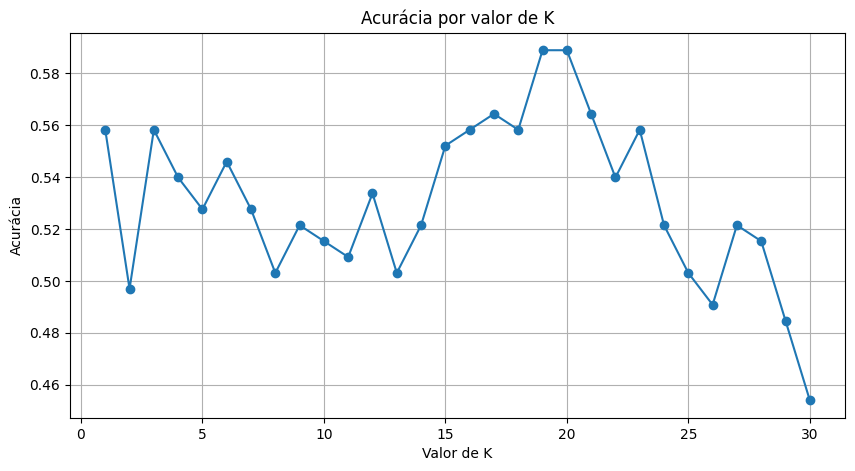

In [ ]:
ks = [r["k"] for r in resultados_k]
acuracias = [r["acuracia_validacao"] for r in resultados_k]

plt.figure(figsize=(10,5))
plt.plot(ks, acuracias, marker='o')

plt.title("Acurácia por valor de K")
plt.xlabel("Valor de K")
plt.ylabel("Acurácia")

plt.grid(True)
plt.show()

# Conclusão

O algoritmo K-NN foi aplicado para classificação de estados do jogo da velha utilizando diferentes valores de K.

Os melhores resultados foram obtidos com k = 19, alcançando aproximadamente 58,9% de acurácia na validação e 54,88% no conjunto de teste.

Os resultados mostraram que o modelo conseguiu classificar parte das configurações do tabuleiro, porém apresentou dificuldades em algumas classes, principalmente devido ao desbalanceamento presente no dataset.